### Модели регрессии

#### Цель работы

Познакомиться с основными приемами работы с моделями регрессии в scikit-learn.

#### Задания для выполнения

1. Загрузите встроенные датасет о ценах на недвижимость в Калифорнии.
3. Постройте модель регрессии для предсказания цены конкретного объекта.
4. Оцените качество построенной модели с помощью визуализации и коэффициента детерминации.
1. Постройте альтернативную полиномиальную модель, сравните ее с предыдущей.

#### Методические указания

В качестве исходных данных будем использовать датасет о ценах на объекты недвижимости в Калифорнии. Это один из известных обучающих наборов данных. Он встроен в библиотеку _sklearn_, так что его не нужно загружать или скачивать отдельно. Для начала работы импортируем стандартные необходимые библиотеки:

In [39]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

Сперва загрузим исходный набор данных:

In [40]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

Сперва следует ознакомиться со структурой тех данных, которые мы получили. Для этого выведем тип полученного объекта:

In [41]:
type(california)

sklearn.utils._bunch.Bunch

Это специальный тип данных библиотеки _sklearn_, который похож по своему устройству на обычный словарь. Поэтому посмотрим, какие ключи есть в этом словаре:

In [42]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

Особый интерес здесь представляют поля _data_ и _target_, которые содержат именно исходные атрибуты и вектор значений целевой переменной. Выведем их тип:

In [43]:
print(type(california.data), type(california.target))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


Так как это массивы _numpy_, то можно посмотреть их форму:

In [44]:
print(california.data.shape, california.target.shape)

(20640, 8) (20640,)


Получается, что в данных  более 20 тысяч строк и 8 атрибутов. Дополнительно можно еще вывести описание датасета для получения дополнительной информации.

In [45]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Теперь с данными можно работать разными способами. Для удобства анализа мы объединим все массивы в датафрейм:

In [46]:
data = pd.DataFrame(california.data, columns = california.feature_names)
data['Price'] = california.target
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Проверим данные на наличие пропущенных значений:

In [47]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Видим, что пропусков в данных нет. Кроме того, видно, что все данные выражены в численных шкалах. Значит, особенной обработки данный датасет не требует, он уже достаточно чистый. Теперь можно вывести основную статистику по датасету:

In [48]:
data.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


Теперь выделим целевую переменную и факторы:

In [49]:
y = data['Price']
X = data.drop('Price', axis=1)

Выведем форму получившихся массивов:

In [50]:
y.shape, X.shape

((20640,), (20640, 8))

Приступим к обучению и оценке качества модели. Из набора линейных моделей библиотеки _sklearn_ импортируем линейную регрессию:

In [51]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Как и в предыдущих работах выведем коэффициенты модели, так как в линейных моделях они имеют некоторый смысл:

In [52]:
print("Coefficients: \n", model.coef_)

Coefficients: 
 [ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]


Выведем коэффициенты вместе с названиями соответствующих атрибутов:

In [53]:
_ = [print(k, v) for k, v in zip(X.columns, model.coef_)]

MedInc 0.4366932931343242
HouseAge 0.00943577803323799
AveRooms -0.10732204139090373
AveBedrms 0.6450656935198109
Population -3.976389421194229e-06
AveOccup -0.00378654265497092
Latitude -0.4213143775271443
Longitude -0.4345137546747775


Проанализируйте эти данные вместе с интерпретацией атрибутов датасетов и сделайте вывод о том, какие факторы как влияют на цену недвижимости в Калифорнии.

MedInc (+0.4367):
При увеличении медианного дохода на 1 единицу (десятки тысяч долларов) цена дома увеличивается в среднем на 0.44 единицы (сотни тысяч долларов). Это ожидаемо: чем богаче район, тем дороже жильё.

HouseAge (+0.0094):
Связь очень слабая (почти нулевая). Возраст домов практически не влияет на цену в этой модели.

AveRooms (-0.1073):
Неожиданно отрицательный коэффициент. Это может быть связано с мультиколлинеарностью (AveRooms и AveBedrms сильно коррелируют) или с тем, что в районах с большим количеством комнат на домохозяйство могут быть большие старые дома, которые не обязательно дорогие.

AveBedrms (+0.6451):
Самый сильный положительный фактор. Увеличение количества спален на домохозяйство на 1 приводит к росту цены на 0.645 (почти на 65 тысяч долларов). Это логично: больше спален — больше площадь — дороже.

Population (-0.000004):
Коэффициент практически равен нулю. Население квартала не влияет на цену дома.

AveOccup (-0.0038):
Отрицательный, но очень слабый. Возможно, районы с более плотным заселением (больше людей на домохозяйство) менее привлекательны для покупателей.

Latitude (-0.4213) и Longitude (-0.4345):
Отрицательные коэффициенты означают, что при движении на север (увеличение широты) и на восток (увеличение долготы, т.е. уменьшение отрицательных значений) цена падает. То есть более южные и западные районы Калифорнии дороже (например, Лос-Анджелес и Сан-Диего против более северных районов).

#### Вывод:
На цену недвижимости в Калифорнии наиболее сильно положительно влияют медианный доход (MedInc) и количество спален (AveBedrms). Географическое положение (широта и долгота) также играет важную роль: южные и западные районы дороже. Количество комнат (AveRooms) показывает неожиданную отрицательную связь, что может указывать на мультиколлинеарность с количеством спален. Возраст домов, население и плотность заселения практически не влияют на цену.

Как и в модели линейной регрессии, данный вектор не включает в себя свободный коэффициент. Он хранится в отдельном поле класса:

In [54]:
print("Intercept: \n", model.intercept_)

Intercept: 
 -36.94192020718444


Сделаем предсказания модели и выведем на экран первые несколько точек:

In [55]:
y_pred = model.predict(X)
print(y_pred[:5])

[4.13164983 3.97660644 3.67657094 3.2415985  2.41358744]


Для сравнения выведем реальные соответствующие значения целевой переменной:

In [56]:
print(y[:5])

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


Конечно, так анализировать данные неудобно. Лучше построить график, демонстрирующий связь между реальными и предсказанными значениями целевой переменной:

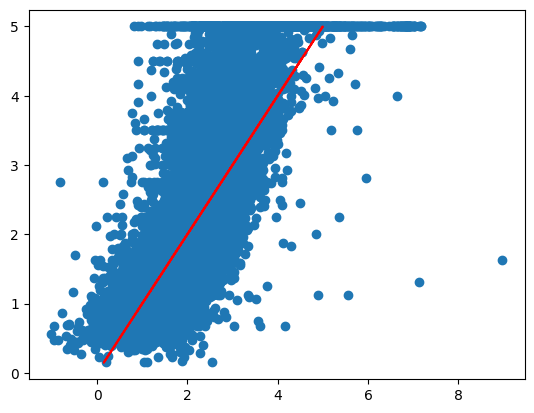

In [57]:
plt.scatter(y_pred, y)
plt.plot(y, y, c='r')

На этом графике чем ближе точки к центральной линии, тем более точные прогнозы делает модель. В данном случае разброс довольно велик. Чтобы оценить эффективность модели численно, опять обратимся к встроенной метрике, реализованной методом _score_ - коэффициенту детерминации:

In [58]:
model.score(X, y)

0.606232685199805

Уровень 0.6 показывает, что модель могла бы быть более точной. Давайте попробуем построить другую модель - полиномиальную регрессию. Есть надежда, что введение полиномиальных признаков может существенно увеличить точность модели:

In [59]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(5).fit_transform(X)

В данном случае используем полиномиальные признаки пятой степени. Вы можете поэкспериментировать с другими степенями полинома. Построим предсказание для анализа:

In [60]:
polynomial = LinearRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

По этим данным можно построить график, подобный предыдущему:

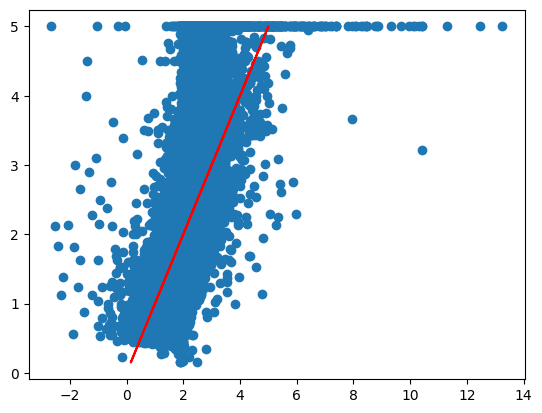

In [61]:
plt.scatter(y_pred_poly, y)
plt.plot(y, y, c='r')

По этому графику можно сделать вывод, что модель стала несколько более точной. Но более конкретно это улучшение можно увидеть при помощи выбранной метрики:

In [62]:
polynomial.score(poly, y)

0.36629180146398177

Полиномиальная регрессия пятой степени показала коэффициент детерминации R² = 0.366, что значительно хуже, чем у линейной модели (R² = 0.606). Это может быть связано с численной неустойчивостью при использовании высоких степеней полинома без предварительной нормализации признаков. Для улучшения качества рекомендуется использовать полином второй степени или применять стандартизацию признаков.

### Контрольные вопросы

**1. Чем отличается применение разных моделей регрессии в бибилиотеке _sklearn_ от моделей классфикации?**  
Модели регрессии предсказывают непрерывную целевую переменную (например, цену дома, температуру), тогда как модели классификации предсказывают дискретную целевую переменную (класс, категорию). В sklearn интерфейс унифицирован: у всех моделей есть методы fit(X, y), predict(X), score(X, y), но метрики качества разные: для регрессии — R², MSE, MAE; для классификации — accuracy, precision, recall, F1 и др.

**2. Что показывает коэффициент детерминации для модели регрессии?**  
Коэффициент детерминации (R²) показывает, какую долю дисперсии целевой переменной объясняет модель. Значение R² лежит в диапазоне от -inf до 1.

R² = 1: модель идеально предсказывает все точки.

R² = 0: модель предсказывает не лучше, чем просто среднее значение.

R² < 0: модель хуже, чем простое усреднение.

**3. Какое значение имеют коэффициенты линейной регрессии?**  
Коэффициенты линейной регрессии показывают, на сколько единиц изменится целевая переменная при увеличении соответствующего признака на одну единицу, при условии, что все остальные признаки остаются неизменными. Знак коэффициента указывает направление связи (положительный — прямая, отрицательный — обратная). Величина коэффициента отражает силу влияния признака (при условии, что признаки приведены к сопоставимым масштабам).

**4. Какие атрибуты имеет объект линейной регрессии?**  
Основные атрибуты LinearRegression после обучения:

coef_ — массив коэффициентов модели (веса признаков).

intercept_ — свободный член (смещение).

rank_ — ранг матрицы признаков (для метода наименьших квадратов).

singular_ — сингулярные значения матрицы признаков.